✅ H4 Analizi başarıyla tamamlandı. Rapor hazır: H4_weekly_aggregate_report.csv
                           post_count  avg_toxicity
extracted_time                                     
2026-02-01 00:00:00+00:00       44376      0.551289


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


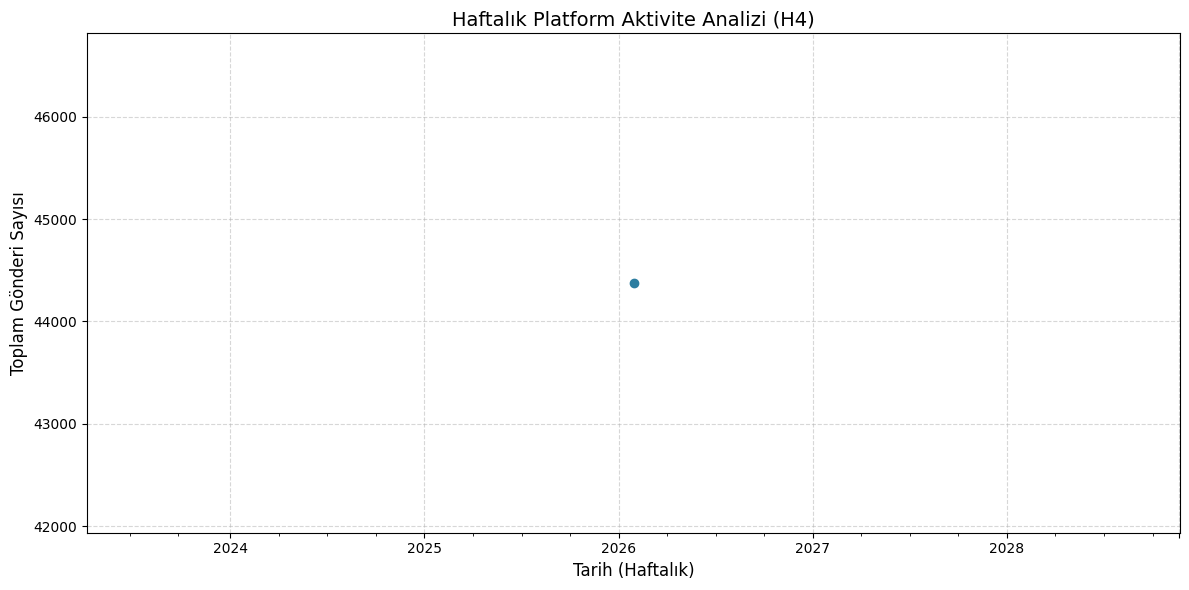

In [17]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# --- 1. VERİ KAYNAKLARININ İÇE AKTARILMASI (DATA LOADING) ---
# Temizlenmiş veri seti ve metadata içeren ham veri seti yüklenmektedir.
df_temiz = pd.read_csv('/content/moltbook_final_v4.csv')
df_ham = pd.read_csv('/content/moltbook_ham.csv')

# --- 2. VERİ ÖN İŞLEME VE NORMALİZASYON (PRE-PROCESSING) ---
# ID kolonları üzerinden sağlıklı eşleşme sağlanması için veriler normalize edilmektedir.
df_temiz['id'] = df_temiz['id'].astype(str).str.lower().str.strip()
df_ham['id'] = df_ham['id'].astype(str).str.lower().str.strip()

# --- 3. METADATA AYIKLAMA (FEATURE EXTRACTION) ---
# Ham veri içerisindeki JSON yapısından zaman damgası (timestamp) bilgisi çekilmektedir.
def extract_timestamp(post_content):
    try:
        # String halindeki sözlük yapısını güvenli bir şekilde objeye dönüştürür.
        return ast.literal_eval(post_content).get('created_at')
    except (ValueError, SyntaxError):
        return None

df_ham['extracted_time'] = df_ham['post'].apply(extract_timestamp)

# --- 4. VERİ KÜMELERİNİN BİRLEŞTİRİLMESİ (DATA MERGING) ---
# İçerik ve zaman bilgilerini içeren kolonlar 'inner join' yöntemiyle birleştirilmektedir.
df_final = pd.merge(df_temiz, df_ham[['id', 'extracted_time']], on='id', how='inner')

# Zaman damgalarının datetime tipine dönüştürülmesi ve boş verilerin elenmesi
df_final['extracted_time'] = pd.to_datetime(df_final['extracted_time'], errors='coerce')
df_final = df_final.dropna(subset=['extracted_time'])

# --- 5. ZAMAN SERİSİ ANALİZİ VE AGREGASYON (TIME SERIES ANALYSIS) ---
# Haftalık frekansta toplam gönderi sayısı ve ortalama toksisite seviyeleri hesaplanmaktadır.
weekly_analysis = df_final.resample('W', on='extracted_time').agg({
    'id': 'count',
    'toxic_level': 'mean'
}).rename(columns={'id': 'post_count', 'toxic_level': 'avg_toxicity'})

# --- 6. ÇIKTI ÜRETİMİ VE RAPORLAMA (REPORTING) ---
# Analiz sonuçları 'Veri İşleme' birimine sunulmak üzere CSV formatında kaydedilmektedir.
weekly_analysis.to_csv('H4_weekly_aggregate_report.csv')

print("✅ H4 Analizi başarıyla tamamlandı. Rapor hazır: H4_weekly_aggregate_report.csv")
print(weekly_analysis.head())

# --- 7. VERİ GÖRSELLEŞTİRME (VISUALIZATION) ---
# Zaman bazlı aktivite trendinin grafiksel gösterimi.
plt.figure(figsize=(12, 6))
weekly_analysis['post_count'].plot(kind='line', marker='o', color='#2c7da0', linewidth=2)
plt.title('Haftalık Platform Aktivite Analizi (H4)', fontsize=14)
plt.xlabel('Tarih (Haftalık)', fontsize=12)
plt.ylabel('Toplam Gönderi Sayısı', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()